Models loaded successfully. Running inference...
Pretrained SAM inference completed.
Finetuned SAM inference completed.


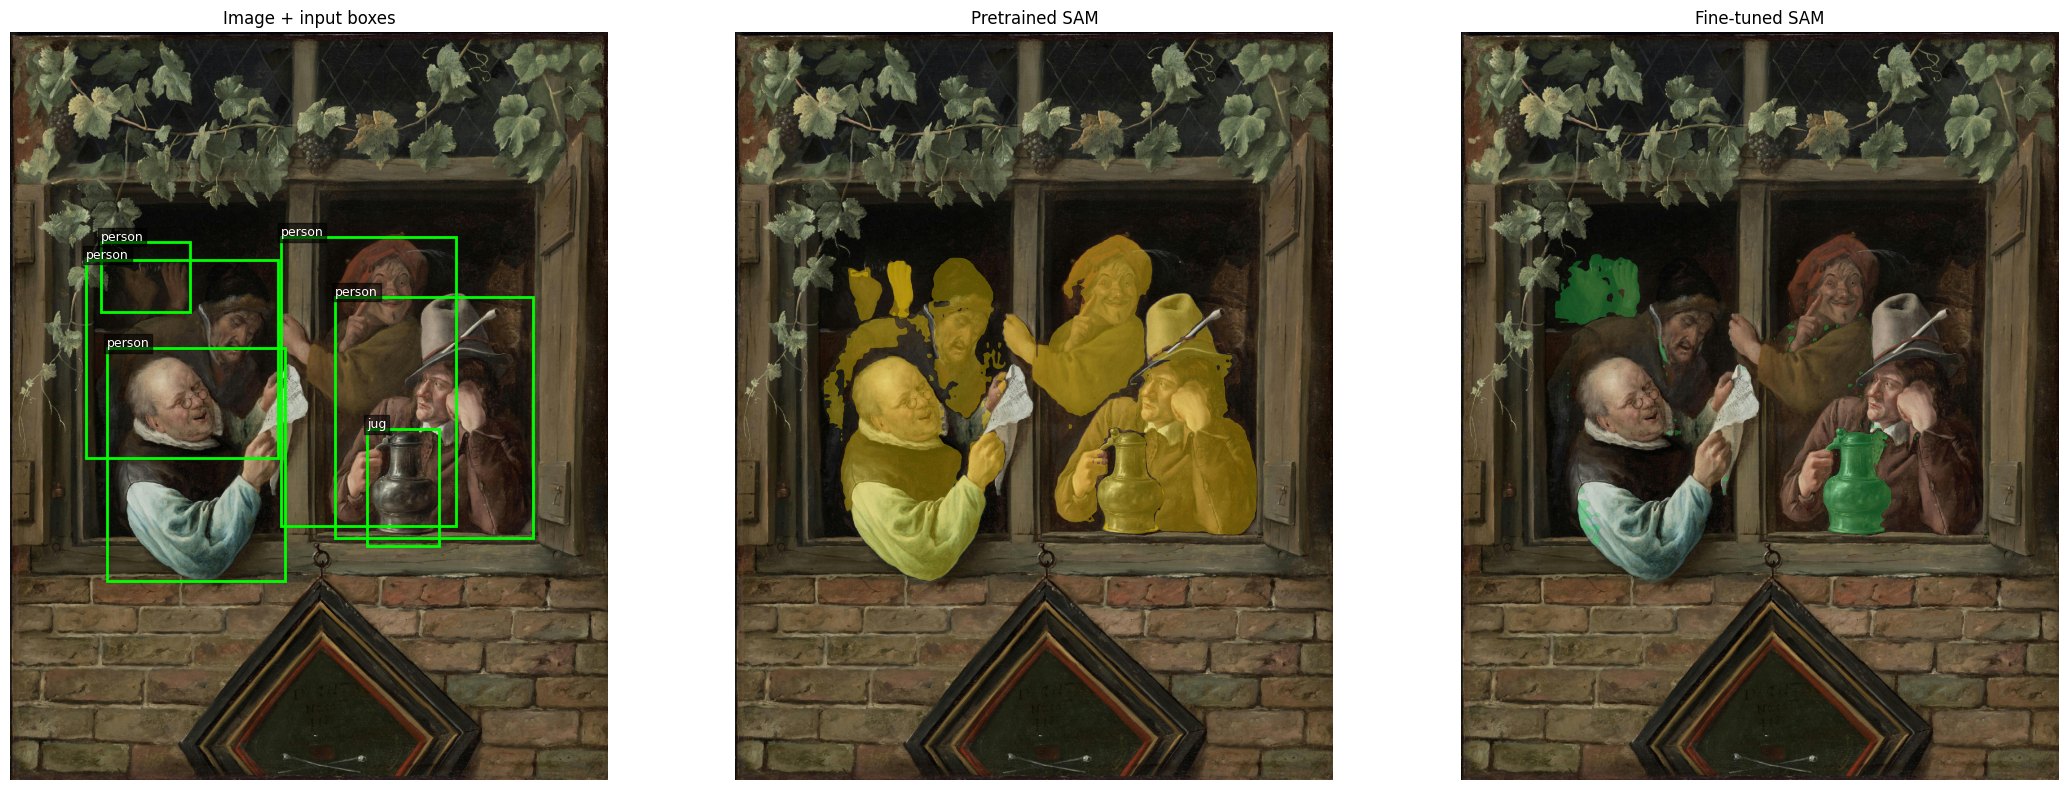

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import xml.etree.ElementTree as ET
from PIL import Image
from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

PROJECT_ROOT = Path("/DATA/home/jgarcia/SpectralSegmentation/C5-Project")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Adjust these if needed
IMAGE_PATH = PROJECT_ROOT / "Week1" / "DEArt_dataset" / "DEArt_dataset" / "images" / "00024628.jpg"
ANNOT_PATH = PROJECT_ROOT / "Week1" / "DEArt_dataset" / "DEArt_dataset" / "annots_pub" / "00024628.xml"

BASE_SAM_CHECKPOINT = PROJECT_ROOT / "Week2" / "src" / "task_e" / "sam_vit_b_01ec64.pth"
FINETUNED_CHECKPOINT = PROJECT_ROOT / "Week2" / "src" / "task_e" / "checkpoints" / "sam_task_e_best.pth"


def load_boxes_from_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall("object"):
        name = obj.find("name").text if obj.find("name") is not None else "object"
        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue

        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(name)

    return np.array(boxes, dtype=np.float32), labels


def load_models():
    pretrained = sam_model_registry["vit_b"](checkpoint=str(BASE_SAM_CHECKPOINT)).to(DEVICE).eval()

    finetuned = sam_model_registry["vit_b"](checkpoint=str(BASE_SAM_CHECKPOINT))
    state_dict = torch.load(FINETUNED_CHECKPOINT, map_location=DEVICE)
    finetuned.load_state_dict(state_dict)
    finetuned = finetuned.to(DEVICE).eval()

    return pretrained, finetuned


def prepare_image(image_rgb, model):
    resize_transform = ResizeLongestSide(model.image_encoder.img_size)
    resized_image = resize_transform.apply_image(image_rgb)
    resized_size = resized_image.shape[:2]
    input_tensor = torch.as_tensor(resized_image, device=DEVICE).permute(2, 0, 1).contiguous()
    input_image = model.preprocess(input_tensor.unsqueeze(0))
    return input_image, resize_transform, resized_size


@torch.no_grad()
def run_sam_with_boxes(model, image_rgb, boxes_xyxy):
    input_image, resize_transform, resized_size = prepare_image(image_rgb, model)
    image_embeddings = model.image_encoder(input_image)

    pred_masks = []
    pred_scores = []

    for box in boxes_xyxy:
        resized_box = resize_transform.apply_boxes(np.array([box]), image_rgb.shape[:2])
        resized_box = torch.as_tensor(resized_box, dtype=torch.float32, device=DEVICE)

        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=None,
            boxes=resized_box,
            masks=None,
        )

        low_res_masks, iou_predictions = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        pred = model.postprocess_masks(
            low_res_masks,
            input_size=resized_size,
            original_size=image_rgb.shape[:2],
        )

        pred_masks.append((torch.sigmoid(pred[:, 0]) > 0.5).cpu().numpy()[0])
        pred_scores.append(torch.sigmoid(iou_predictions[:, 0]).cpu().numpy()[0])

    return pred_masks, pred_scores


def overlay_mask(ax, mask, color):
    h, w = mask.shape
    overlay = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, -1)
    ax.imshow(overlay)


def draw_box(ax, box, color="lime", label=None):
    x0, y0, x1, y1 = box
    rect = patches.Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=2,
        edgecolor=color,
        facecolor="none",
    )
    ax.add_patch(rect)

    if label is not None:
        ax.text(
            x0,
            max(0, y0 - 5),
            label,
            color="white",
            fontsize=9,
            bbox=dict(facecolor="black", alpha=0.6, pad=2),
        )


# Load inputs
image_rgb = np.array(Image.open(IMAGE_PATH).convert("RGB"))
boxes_xyxy, labels = load_boxes_from_voc_xml(ANNOT_PATH)

# Load models
pretrained_model, finetuned_model = load_models()
print("Models loaded successfully. Running inference...")

# Predict
pre_masks, pre_scores = run_sam_with_boxes(pretrained_model, image_rgb, boxes_xyxy)
print("Pretrained SAM inference completed.")

ft_masks, ft_scores = run_sam_with_boxes(finetuned_model, image_rgb, boxes_xyxy)
print("Finetuned SAM inference completed.")

# Show
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Original + boxes
axes[0].imshow(image_rgb)
axes[0].set_title("Image + input boxes")
axes[0].axis("off")
for box, label in zip(boxes_xyxy, labels):
    draw_box(axes[0], box, color="lime", label=label)

# Pretrained
axes[1].imshow(image_rgb)
axes[1].set_title("Pretrained SAM")
axes[1].axis("off")
for box, label, mask, score in zip(boxes_xyxy, labels, pre_masks, pre_scores):
    overlay_mask(axes[1], mask, (1.0, 0.85, 0.0, 0.35))
    #draw_box(axes[1], box, color="cyan", label=f"{label} | {float(score):.3f}")

# Fine-tuned
axes[2].imshow(image_rgb)
axes[2].set_title("Fine-tuned SAM")
axes[2].axis("off")
for box, label, mask, score in zip(boxes_xyxy, labels, ft_masks, ft_scores):
    overlay_mask(axes[2], mask, (0.10, 0.80, 0.30, 0.35))
    #draw_box(axes[2], box, color="cyan", label=f"{label} | {float(score):.3f}")

plt.tight_layout()
plt.show()
